In [115]:
from typing import Literal, TypedDict

from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

load_dotenv()

True

In [116]:
model= ChatMistralAI(model='mistral-medium-latest')

In [117]:
class PodcastDetails(BaseModel):
    topic: str = Field(description="The main topic of the podcast episode")
    host_persona: dict = Field(
        description=(
            "Details about the host in JSON format that would help build a unique persona with at least 4 traits (e.g. vocabulary level, humor style, catchphrases, energy level)"
        )
    )
    guest_persona: dict = Field(
        description=(
            "Details about the guest in JSON format that would help build a unique persona with at least 4 traits (e.g. expertise, speaking style, personality quirks, communication approach)"
        )
    )
    podcast_name: str = Field(
        description=(
            "Name or Title of the podcast"
        )
    )
    platform_name: str = Field(
        description=(
            "Name or Title of the platform hosting the podcast"
        )
    )

In [118]:
detail_model= model.with_structured_output(PodcastDetails)

In [119]:
class ScriptGen(TypedDict):
    user_input: str

    podcast_name: str
    platform_name: str
    topic: str
    host_persona: dict
    guest_persona: dict

    segments: list[dict]
    current_segment: str

    is_complete: bool
    human_feedback: str

In [120]:
SEGMENT_ORDER = ["welcome", "intro", "discussion", "outro"]

SEGMENT_GUIDELINES = {
    "welcome": (
        "The host warmly welcomes the audience, sets the mood and energy, and teases the episode's topic. Keep it punchy. 2-3 exchanges."
    ),
    "intro": (
        "The host introduces the guest by name and credentials. The guest shares a brief personal background and why the topic matters to them. 3-4 exchanges."
    ),
    "discussion": (
        "A deep, substantive dive into the topic. The host asks probing, open-ended questions; the guest gives rich, detailed answers with examples and anecdotes. Number of exchanges depends on how detailed the topic needs to be."
    ),
    "outro": (
        "The host and guest summarise key takeaways, the guest shares where listeners can learn more, and the host thanks the guest and signs off. 2-3 exchanges."
    ),
}

In [121]:
def parse_input_node(state: ScriptGen) -> ScriptGen:
    """Parse user input and extract topic + personas as JSON."""
    user_input = state["user_input"]
    
    details = detail_model.invoke(user_input)
    
    return {
        "topic": details.topic,
        "host_persona": details.host_persona,
        "guest_persona": details.guest_persona,
        "podcast_name": details.podcast_name,
        "platform_name": details.platform_name,
        "current_segment": "welcome",
        "segments": [],
        "is_complete": False
    }

def generate_segment_node(state: ScriptGen) -> ScriptGen:
    """Generate the next segment, or regenerate the last one if feedback exists."""
    
    current_segment = state["current_segment"]
    topic = state["topic"]
    podcast_name = state["podcast_name"]
    platform_name = state["platform_name"]
    host = state["host_persona"]
    guest = state["guest_persona"]
    segments = list(state.get("segments", []))          
    feedback = state.get("human_feedback", "").strip()

    # ── Case 1: Re-generate the last segment with human feedback ──
    if feedback and segments:
        last = segments[-1]
        prompt = f"""You are a podcast script writer. Rewrite the following 
                    "{last['type']}" segment based on the reviewer's feedback.

                    --- ORIGINAL SEGMENT ---
                    {last['content']}

                    --- REVIEWER FEEDBACK ---
                    {feedback}

                    --- CONTEXT ---
                    Podcast Name  : {podcast_name}
                    Platform Name : {platform_name}
                    Topic         : {topic}
                    Host          : {host}
                    Guest         : {guest}

                    Rules:
                    • Keep the HOST: / GUEST: label format.
                    • Ensure the host and guest voices remain clearly distinct.
                    • Apply the feedback precisely; do not change anything the reviewer didn't mention.
                    """
        response = model.invoke(prompt)
        segments[-1] = {
            "type": last["type"],
            "content": response.content,
        }
        return {"segments": segments, "human_feedback": ""}

    # ── Case 2: Generate a brand-new segment ──
    previous_context = ""
    if segments:
        prev_text = "\n\n".join(
            f"=== {s['type'].upper()} ===\n{s['content']}" for s in segments
        )
        previous_context = (
            f"Here are the segments generated so far (for continuity):\n"
            f"{prev_text}\n\n"
        )

    prompt = f"""You are a podcast script writer.  Write the 
                "{current_segment}" segment for a podcast episode.

                Podcast Name  : {podcast_name}
                Platform Name : {platform_name}
                Topic         : {topic}
                Host persona  : {host}
                Guest persona : {guest}

                Segment guidelines: {SEGMENT_GUIDELINES[current_segment]}

                {previous_context}

                Rules:
                • Format every line as  HOST: <dialogue>  or  GUEST: <dialogue>.
                • The host's language, vocabulary, and energy MUST reflect their persona.
                • The guest's language, vocabulary, and energy MUST reflect their persona.
                • The dialogue must sound natural — include filler words, reactions, 
                interruptions where appropriate.
                • Do NOT include stage directions or parentheticals.
            """
    response = model.invoke(prompt)
    segments.append({
        "type": current_segment,
        "content": response.content,
    })
    return {"segments": segments, "human_feedback": ""}


def human_interrupt_node(state: ScriptGen) -> ScriptGen:
    """Passthrough node. The graph pauses BEFORE this node so the human
    can inspect the latest segment and optionally set `human_feedback`
    via `update_state`.  When the graph resumes this node simply
    passes the (possibly updated) state forward."""
    return {}


def check_completion_node(state: ScriptGen) -> ScriptGen:
    """Advance `current_segment` to the next in order, or flag completion."""
    
    current = state["current_segment"]
    idx = SEGMENT_ORDER.index(current)

    if idx >= len(SEGMENT_ORDER) - 1:
        return {"is_complete": True}

    return {
        "current_segment": SEGMENT_ORDER[idx + 1],
        "is_complete": False,
    }



def after_human_review(state: ScriptGen) -> Literal["generate_segment", "check_completion"]:
    """If the reviewer left feedback → regenerate.  Otherwise → move on."""
    
    if state.get("human_feedback", "").strip():
        return "generate_segment"
    return "check_completion"


def should_continue(state: ScriptGen) -> Literal["generate_segment", "end"]:
    """After check_completion: generate next segment or finish."""
    
    if state.get("is_complete", False):
        return "end"
    return "generate_segment"

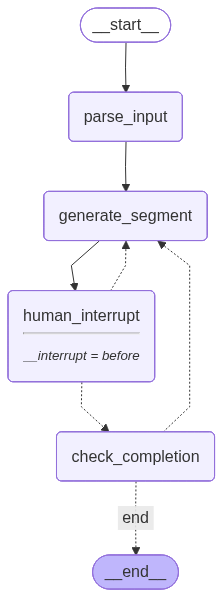

In [122]:
graph = StateGraph(ScriptGen)

graph.add_node("parse_input", parse_input_node)
graph.add_node("generate_segment", generate_segment_node)
graph.add_node("human_interrupt", human_interrupt_node)
graph.add_node("check_completion", check_completion_node)

graph.add_edge(START, "parse_input")
graph.add_edge("parse_input", "generate_segment")
graph.add_edge("generate_segment", "human_interrupt")

graph.add_conditional_edges(
    "human_interrupt",
    after_human_review,
    {
        "generate_segment": "generate_segment",
        "check_completion": "check_completion",
    },
)

graph.add_conditional_edges(
    "check_completion",
    should_continue,
    {
        "generate_segment": "generate_segment",
        "end": END,
    },
)

memory = InMemorySaver()  

compiled_graph = graph.compile(
    interrupt_before=["human_interrupt"],
    checkpointer=memory,
)

compiled_graph

In [123]:
initial_state = {
    'user_input': 'Podcast called Test on the platform spoootify about wildlife with a uneducated host and a guest with PhD in wildlife health'
}
config= {'configurable':{'thread_id': '1'}}

final_state = compiled_graph.invoke(initial_state, config)
final_state

{'user_input': 'Podcast called Test on the platform spoootify about wildlife with a uneducated host and a guest with PhD in wildlife health',
 'podcast_name': 'Test',
 'platform_name': 'spoootify',
 'topic': 'wildlife',
 'host_persona': {'vocabulary_level': 'basic and informal, often uses slang or incorrect terms',
  'humor_style': 'goofy and unintentional, often laughs at own mistakes',
  'catchphrases': ["Oh man, that's wild!",
   "I didn't know that, no way!",
   'Hold up, what?',
   "You're kidding me, right?"],
  'energy_level': 'high but scattered, easily distracted',
  'knowledge_level': 'low, frequently misunderstands concepts',
  'personality_quirks': 'overly excited, interrupts often, asks obvious questions'},
 'guest_persona': {'expertise': 'wildlife health, specifically disease ecology and conservation medicine',
  'speaking_style': 'clear, articulate, and patient, but occasionally uses technical terms',
  'personality_quirks': "calm and composed, enjoys explaining complex 

In [124]:
snapshot = compiled_graph.get_state(config)
print("Next node to execute:", snapshot.next)
print("Current segment:", snapshot.values["current_segment"])
print("Segments so far:", len(snapshot.values["segments"]))

print(snapshot.values["segments"][-1]["content"])

Next node to execute: ('human_interrupt',)
Current segment: welcome
Segments so far: 1
**HOST:** Yo yo yo, welcome back to *Test*—the podcast where we, uh… test stuff? Or talk about stuff? Wait, no, today we’re talking about *wildlife*, baby! And let me tell ya, I saw a squirrel the other day just *vibing* on a power line like it owned the place, and I was like—*Oh man, that’s wild!* Literally! Wild! Like, what’s that little guy’s rent? Does he pay in acorns? I got questions!

**GUEST:** *laughs* Well, I can’t speak to squirrel real estate, but I *can* tell you they’re actually part of a much bigger story—one that connects tiny creatures like that to entire ecosystems, diseases, even *us* sometimes.

**HOST:** Hold up, what? *Us*? Like, you’re saying Mr. Squirrel out there could be, like… plotting against humanity? Is this a *Planet of the Apes* situation but with rodents? *You’re kidding me, right?*

**GUEST:** Not quite—though I love the imagination. But diseases *do* jump between an

In [125]:
final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node to execute:", snapshot.next)
print("Current segment:", snapshot.values["current_segment"])
print("Segments so far:", len(snapshot.values["segments"]))

print(snapshot.values["segments"][-1]["content"])

Next node to execute: ('human_interrupt',)
Current segment: intro
Segments so far: 2
**HOST:** Alright, alright, before we dive into this *wild*—pun absolutely intended—conversation, I gotta introduce our *amazing* guest today! We got Dr. Elena Vasquez here, who is, like… a *wildlife health detective*? A *disease whisperer*? I don’t even know what to call you, but your title is *way* fancier than anything I’ve ever had. You’re a—what was it again?—*conservation medicine* expert? *Disease ecology* person? Man, I already forgot, and I *just* read it!

**GUEST:** *laughs* You’re close! I’m a wildlife veterinarian specializing in disease ecology and conservation medicine. Basically, I study how diseases move between animals, and how that affects *all* of us—humans included.

**HOST:** Ohhh, so like… if a raccoon sneezes in the forest, you’re the one who figures out if *we* should be worried? That’s *so* cool! But wait—how’d you even *get* into this? Did you, like, watch *too* much *Animal 

In [126]:
final_state= compiled_graph.update_state(
    config,
    {"human_feedback": "Make the host sound more excited about the topic."},
    as_node="human_interrupt"
)

# Resume → human_interrupt → routes back to generate_segment (rewrites welcome) → pauses again
# final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node:", snapshot.next)
print("Current segment:", snapshot.values["current_segment"])  # "intro"
print("Segments so far:", len(snapshot.values["segments"]))     # 2
print(snapshot.values["segments"][-1]["content"])

Next node: ('generate_segment',)
Current segment: intro
Segments so far: 2
**HOST:** Alright, alright, before we dive into this *wild*—pun absolutely intended—conversation, I gotta introduce our *amazing* guest today! We got Dr. Elena Vasquez here, who is, like… a *wildlife health detective*? A *disease whisperer*? I don’t even know what to call you, but your title is *way* fancier than anything I’ve ever had. You’re a—what was it again?—*conservation medicine* expert? *Disease ecology* person? Man, I already forgot, and I *just* read it!

**GUEST:** *laughs* You’re close! I’m a wildlife veterinarian specializing in disease ecology and conservation medicine. Basically, I study how diseases move between animals, and how that affects *all* of us—humans included.

**HOST:** Ohhh, so like… if a raccoon sneezes in the forest, you’re the one who figures out if *we* should be worried? That’s *so* cool! But wait—how’d you even *get* into this? Did you, like, watch *too* much *Animal Planet* as

In [128]:
final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node:", snapshot.next)
print("Current segment:", snapshot.values["current_segment"])  
print("Segments so far:", len(snapshot.values["segments"]))     
print(snapshot.values["segments"][-1]["content"])

Next node: ('human_interrupt',)
Current segment: discussion
Segments so far: 3
=== DISCUSSION ===

**HOST:** Alright, Dr. Elena, I gotta ask—because I am *terrible* at science—what even *is* disease ecology? Like, is it, uh… studying when animals get *hangry*? Or is it more like *CSI: Jungle Edition* where you’re out there with, like, a tiny lab coat for ants, solving crimes?

**GUEST:** *laughs* Okay, so—imagine if you had a giant web, right? And every thread is a different animal, plant, or even a *microbe*. Disease ecology is basically figuring out *how* stuff moves through that web. Like, if a fox gets sick, does it stay with the foxes? Or does it jump to rabbits? Or—*oh no*—to *us*? And *why*? Is it because we cut down too many trees? Because the climate’s changing? Because some poor raccoon ate a *questionable* snack behind a dumpster? It’s all connected.

**HOST:** *HOLD UP, WHAT?* So you’re telling me a raccoon’s *late-night trash buffet* could, like… start a *plague*?! Oh man,

In [129]:
final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node:", snapshot.next)
print("Current segment:", snapshot.values["current_segment"])  
print("Segments so far:", len(snapshot.values["segments"]))     
print(snapshot.values["segments"][-1]["content"])

Next node: ('human_interrupt',)
Current segment: outro
Segments so far: 4
**HOST:** Okay, okay, *hold up*—we gotta wrap this up, but *first*, Dr. Elena, hit me with the *biggest* takeaways from today. Like, if someone was *half-listening* while scrolling TikTok (no judgment, that’s *me* every day), what’s the *one* thing they *need* to remember?

**GUEST:** *laughs* Alright, here’s the TL;DR: **Wildlife health = our health.** When we mess with nature—cutting down forests, letting cats roam, ignoring sick animals—we’re *rolling the dice* on new diseases. But the *good* news? We can *help* just by being smarter: don’t feed wildlife, vaccinate pets, and *please* stop kissing turtles.

**HOST:** *I DIDN’T KNOW THAT, NO WAY!* Wait—so if I *see* a sick-looking raccoon, I should *not* try to nurse it back to health with, like, *cheese puffs* and a tiny blanket? *That’s* my go-to move!

**GUEST:** *chuckles* Call your local wildlife rehab *instead*. Cheese puffs are… not a balanced diet for ra

In [130]:
final_state = compiled_graph.invoke(None, config)

# Verify completion
snapshot = compiled_graph.get_state(config)
print("Is complete:", snapshot.values["is_complete"])  # True
print("Next node:", snapshot.next)

Is complete: True
Next node: ()


In [131]:
for seg in snapshot.values["segments"]:
    print(f"\n{'='*50}")
    print(f"  {seg['type'].upper()}")
    print(f"{'='*50}")
    print(seg["content"])


  WELCOME
**HOST:** Yo yo yo, welcome back to *Test*—the podcast where we, uh… test stuff? Or talk about stuff? Wait, no, today we’re talking about *wildlife*, baby! And let me tell ya, I saw a squirrel the other day just *vibing* on a power line like it owned the place, and I was like—*Oh man, that’s wild!* Literally! Wild! Like, what’s that little guy’s rent? Does he pay in acorns? I got questions!

**GUEST:** *laughs* Well, I can’t speak to squirrel real estate, but I *can* tell you they’re actually part of a much bigger story—one that connects tiny creatures like that to entire ecosystems, diseases, even *us* sometimes.

**HOST:** Hold up, what? *Us*? Like, you’re saying Mr. Squirrel out there could be, like… plotting against humanity? Is this a *Planet of the Apes* situation but with rodents? *You’re kidding me, right?*

**GUEST:** Not quite—though I love the imagination. But diseases *do* jump between animals and humans more than you’d think. That’s actually what I study—how wil